## Importing Libraries and Settings

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from category_encoders import CatBoostEncoder
from feature_engine.encoding import OneHotEncoder
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from feature_engine.wrappers import SklearnTransformerWrapper
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier 

import shap
from plots import value_maps, display_model_dashboard, feature_importance_logit, shap_waterfalls_dashboard

from sklearn import set_config
import warnings

set_config(transform_output="pandas")
warnings.filterwarnings("ignore")

## Data Loading and Basic Preprocessing

In [2]:
df = pd.read_csv('../data/heart_disease_clean.csv')
print(df.shape)
df_clean = df.dropna()
df_clean.shape

(303, 14)


(297, 14)

In [3]:
df.head()

,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
discrete = [var for var in df_clean.columns if var != 'target' and var != 'Diseased Vessels' and df_clean[var].nunique() < 10]
continuous = [var for var in df_clean.columns if var != 'target' and var != 'Diseased Vessels' and var not in discrete]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df_clean.drop('target', axis=1), df_clean['target'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((237, 13), (60, 13))

## Baseline Models Evaluation

In [6]:
preprocessor = Pipeline(steps=[

    # Yeo-Johnson transformation
    #('yeo_johnson', YeoJohnsonTransformer(variables=continuous)),
    
    # Scaling 
    ('num_scaler', SklearnTransformerWrapper(transformer=StandardScaler(), variables=continuous)),
    #('num_scaler', SklearnTransformerWrapper(transformer=MinMaxScaler(), variables=continuous)),
    #('num_scaler', SklearnTransformerWrapper(transformer=RobustScaler(), variables=continuous)),
    
    # Encoding 
   # ('cat_encoder', OneHotEncoder(variables=discrete, drop_last=True)),
    #('cat_encoder', CatBoostEncoder(cols=discrete)),
])

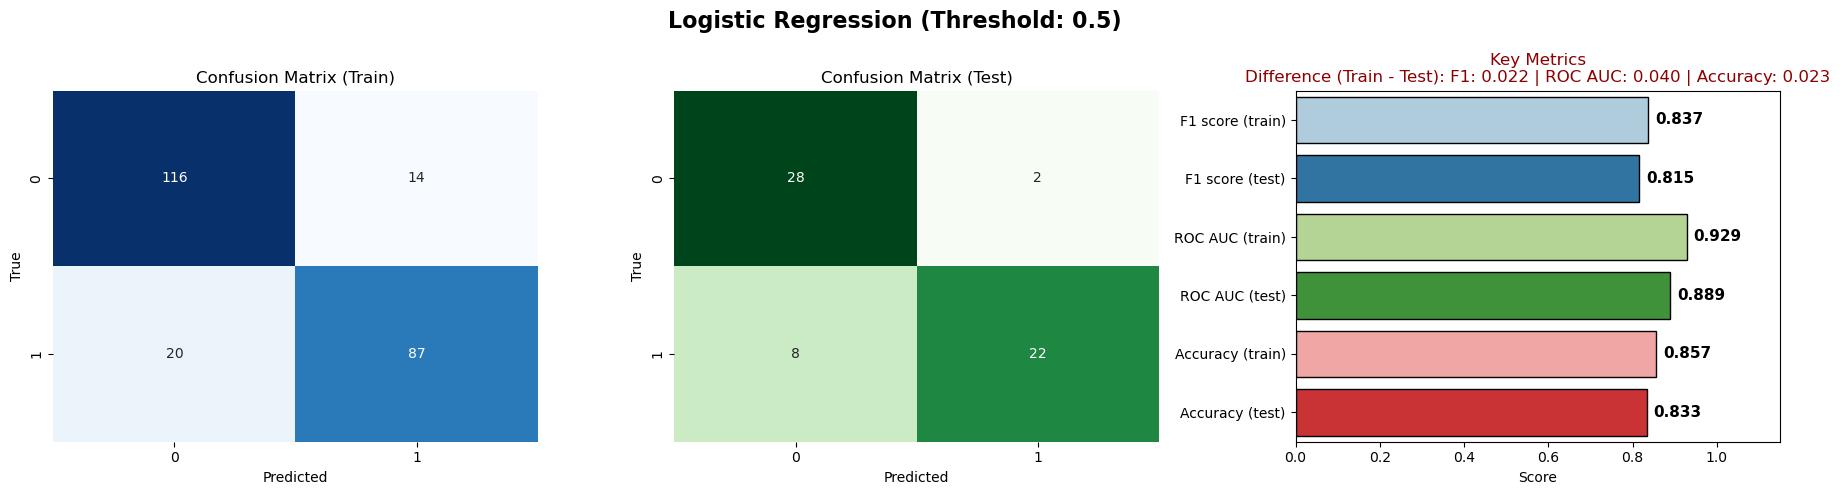

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.778,0.933,0.848,30.000
1,0.917,0.733,0.815,30.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.847,0.833,0.832,60.000
weighted avg,0.847,0.833,0.832,60.000


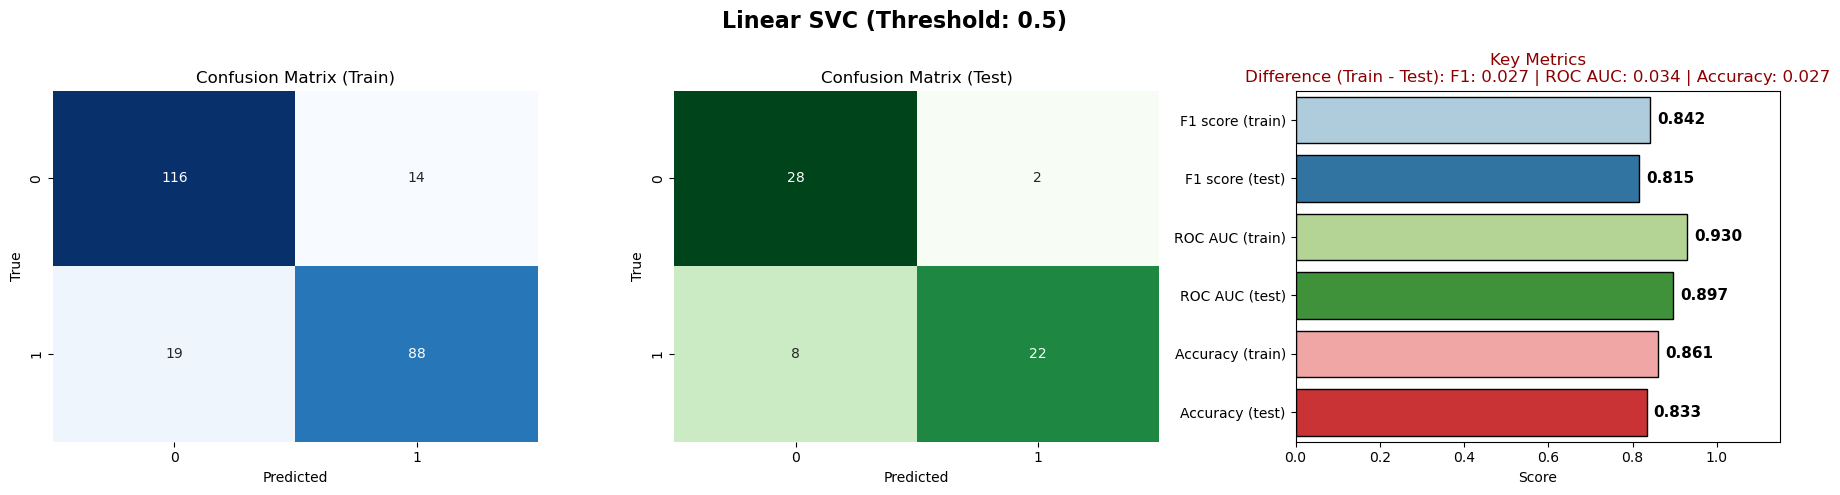

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.778,0.933,0.848,30.000
1,0.917,0.733,0.815,30.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.847,0.833,0.832,60.000
weighted avg,0.847,0.833,0.832,60.000


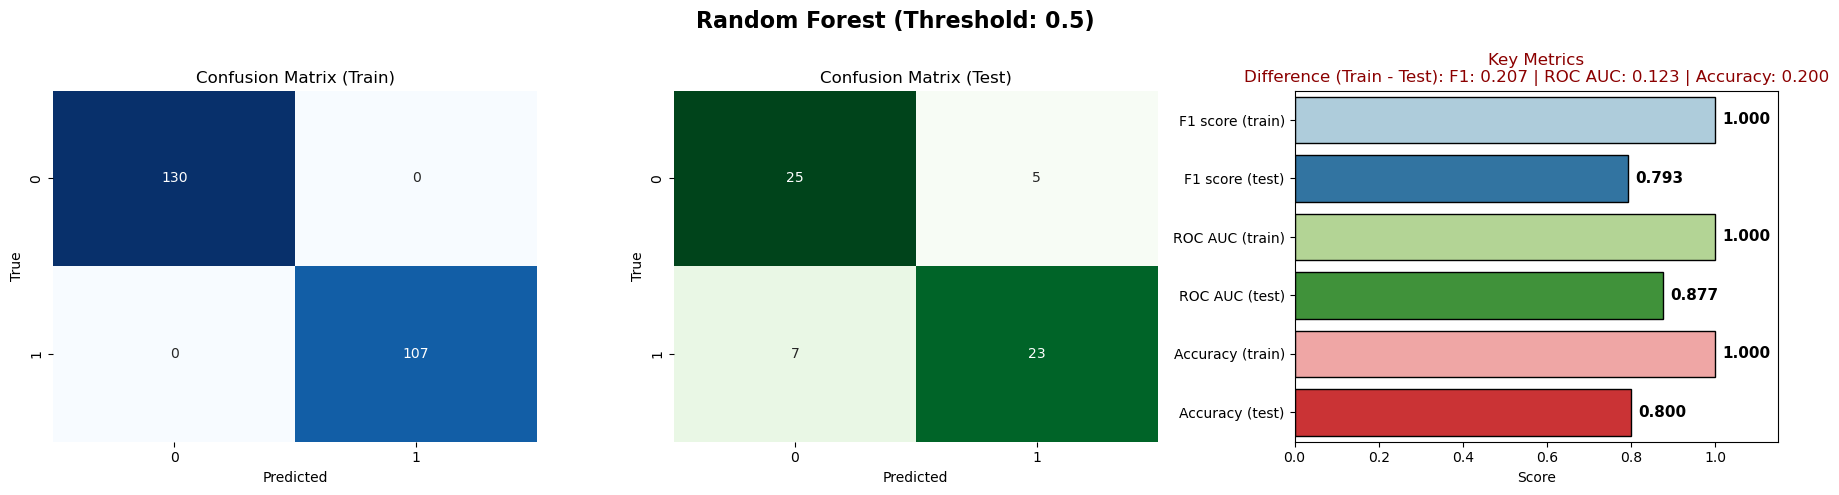

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.781,0.833,0.806,30.0
1,0.821,0.767,0.793,30.0
accuracy,0.800,0.800,0.800,0.8
macro avg,0.801,0.800,0.800,60.0
weighted avg,0.801,0.800,0.800,60.0


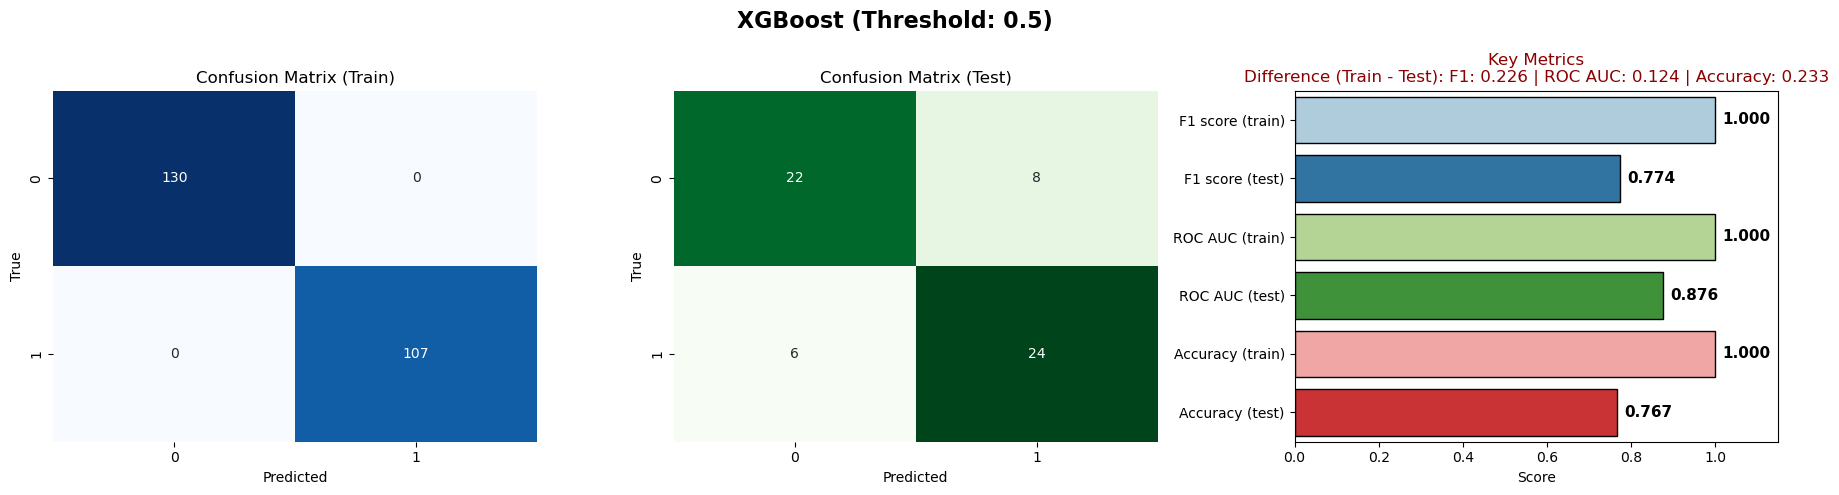

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.786,0.733,0.759,30.000
1,0.750,0.800,0.774,30.000
accuracy,0.767,0.767,0.767,0.767
macro avg,0.768,0.767,0.766,60.000
weighted avg,0.768,0.767,0.766,60.000


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=0),
    "Linear SVC": LinearSVC(max_iter=1000, random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0, n_estimators=100),
    "XGBoost": XGBClassifier(n_estimators=300, random_state=0)
}

pipelines = {name: Pipeline([("preprocessor", preprocessor), ("model", model)])
             for name, model in models.items()}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    display_model_dashboard(name, pipe, X_train, y_train, X_test, y_test)

* Various combinations of transformations were tested:
    * Distribution normalization via `Yeo-Johnson`,
    * Different scaling options (`MinMaxScaler`, `RobustScaler`),
    * And encoding methods (`OneHot`, `CatBoostEncoder`).
* Practice has shown that complicating the pipeline at this stage does not yield any improvement in metrics.
* The most stable setup proved to be a minimalist configuration—using the classic `StandardScaler`.

**Analysis of Model Results:**

* **Linear Models (Logistic Regression and Linear SVC):**
    * Demonstrated excellent generalization capability.
    * The difference in metrics between the training and test sets is minimal.

* **Tree-based Models and Boosting (Random Forest and XGBoost):**
    * Displayed overfitting on "out-of-the-box" settings.
    * Both models perfectly memorized the training dataset (`Accuracy`, `F1`, `ROC AUC = 1.000`),
    * But the metrics drop significantly on the test data.

**Summary:** Linear models perform stably, whereas tree-based models and boosting algorithms should not be left with their default parameters.

## Hyperparameter Grid Setup (GridSearchCV)

In [8]:
# Logistic Regression
# saga/liblinear support both types of regularization
logreg_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000, 5000]
}

# Linear SVC
linsvc_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'dual': [False, True] 
}


# Trees 

# Random Forest
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [1, 2, 4],
    'min_samples_leaf': [1, 2, 4, 5]
}

# Boosting models

# Gradient Boosting 
gb_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# XGBoost
xgb_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# LightGBM
lgbm_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0]
}

# CatBoost
catboost_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6, 8],
    'silent': [True]
}

In [9]:
# List of dictionaries with configurations for each model
models_config = [
    {
        'name': 'Logistic Regression',
        'estimator': LogisticRegression(random_state=0),  
        'param_grid': logreg_grid
    },
    {
        'name': 'SVC',
        'estimator': LinearSVC(random_state=0), 
        'param_grid': linsvc_grid
    },
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(random_state=0, class_weight='balanced'),
        'param_grid': rf_grid
    },
    {
        'name': 'Gradient Boosting',
        'estimator': GradientBoostingClassifier(random_state=0), 
        'param_grid': gb_grid
    },
    {
        'name': 'XGBoost',
        'estimator': XGBClassifier(random_state=0),
        'param_grid': xgb_grid
    },
    {
        'name': 'LGBM Classifier',
        'estimator': LGBMClassifier(random_state=0, verbose=-1), 
        'param_grid': lgbm_grid
    },
    {
        'name': 'CatBoost Classifier',
        'estimator': CatBoostClassifier(random_state=0),
        'param_grid': catboost_grid
    }
]

In [10]:
df = pd.read_csv('../data/heart_disease_clean.csv')

df_clean = df.dropna()
yeojohnson_col = ['Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
#df_clean.loc[:, 'Resting ECG'] = df_clean['Resting ECG'].replace(2, 1).copy()
#df_clean = df_clean.drop(columns=['Blood Sugar >120'])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df_clean.drop('target', axis=1), df_clean['target'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((237, 13), (60, 13))

## Model Training and Hyperparameter Tuning

In [12]:
preprocessor = Pipeline(steps=[

    # Yeo-Johnson transformation
    ('yeo_johnson', YeoJohnsonTransformer(variables=continuous)),
    
    # Scaling 
    #('num_scaler', SklearnTransformerWrapper(transformer=StandardScaler(), variables=continuous)),
    ('num_scaler', SklearnTransformerWrapper(transformer=MinMaxScaler(), variables=continuous)),
    #('num_scaler', SklearnTransformerWrapper(transformer=RobustScaler(), variables=continuous)),
    
    # Encoding 
    #('cat_encoder', OneHotEncoder(variables=discrete, drop_last=True)),
    #('cat_encoder', CatBoostEncoder(cols=discrete)),
])

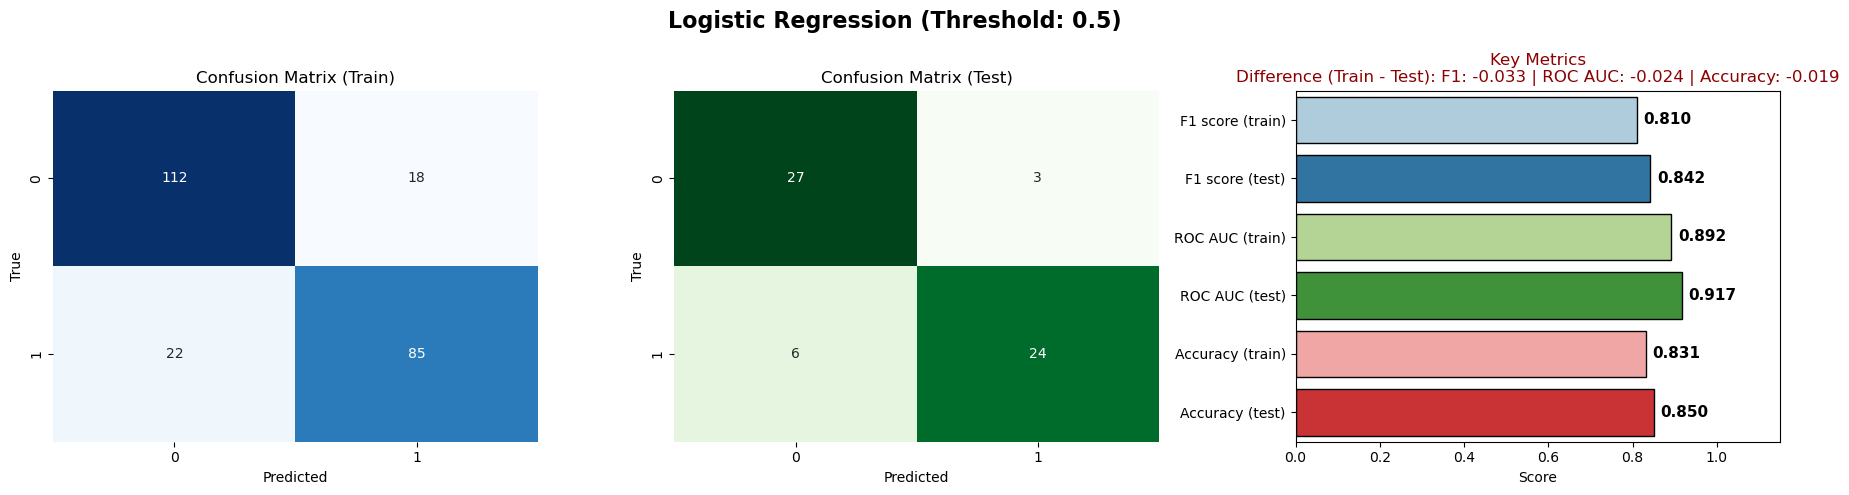

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.818,0.90,0.857,30.00
1,0.889,0.80,0.842,30.00
accuracy,0.850,0.85,0.850,0.85
macro avg,0.854,0.85,0.850,60.00
weighted avg,0.854,0.85,0.850,60.00


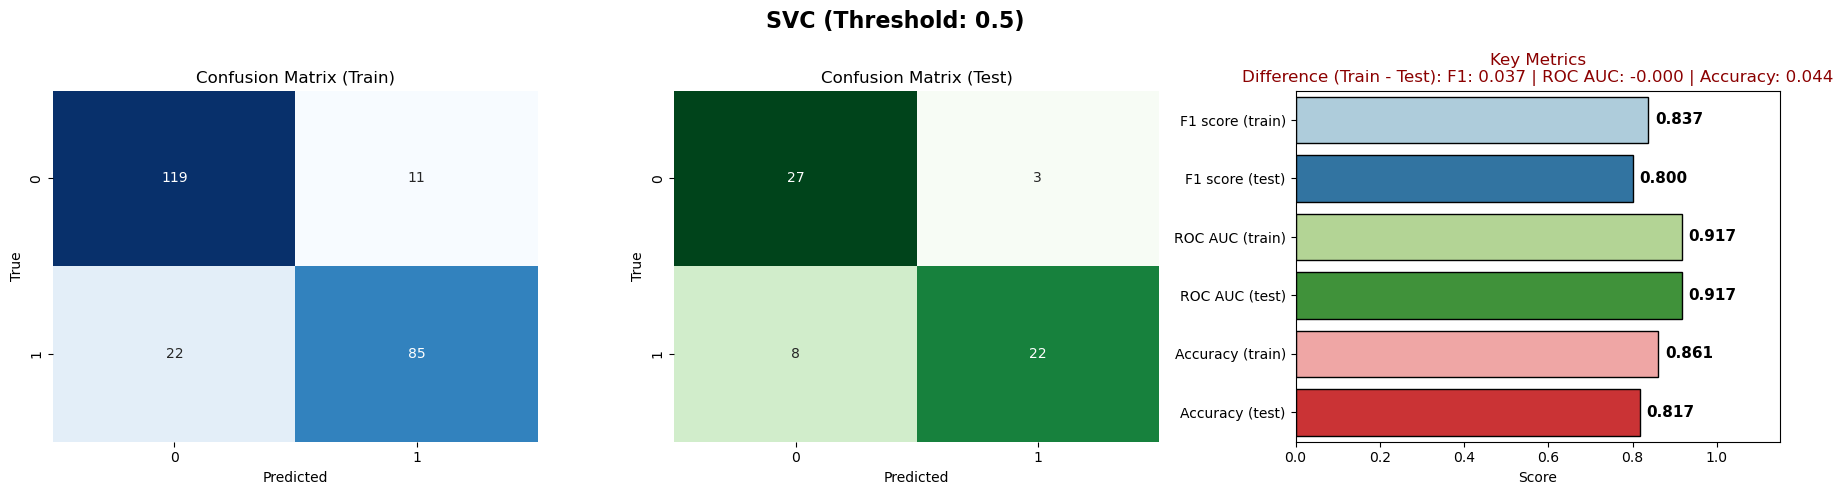

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.771,0.900,0.831,30.000
1,0.880,0.733,0.800,30.000
accuracy,0.817,0.817,0.817,0.817
macro avg,0.826,0.817,0.815,60.000
weighted avg,0.826,0.817,0.815,60.000


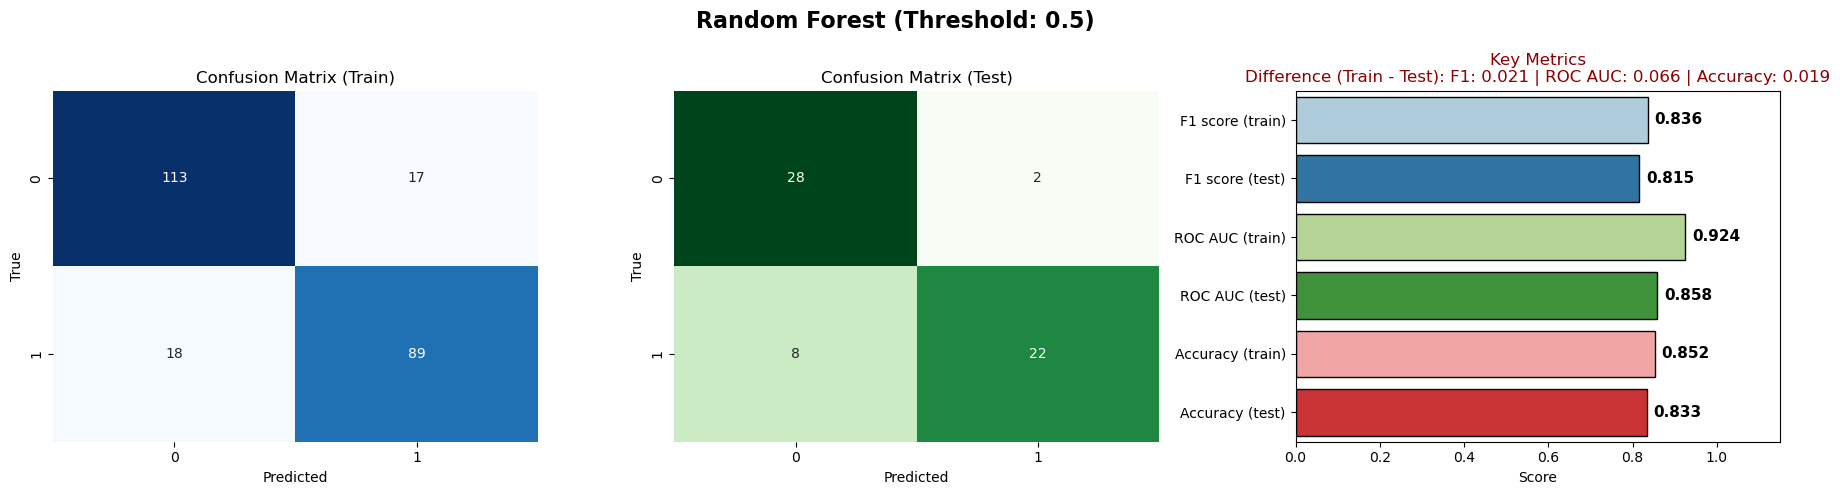

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.778,0.933,0.848,30.000
1,0.917,0.733,0.815,30.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.847,0.833,0.832,60.000
weighted avg,0.847,0.833,0.832,60.000


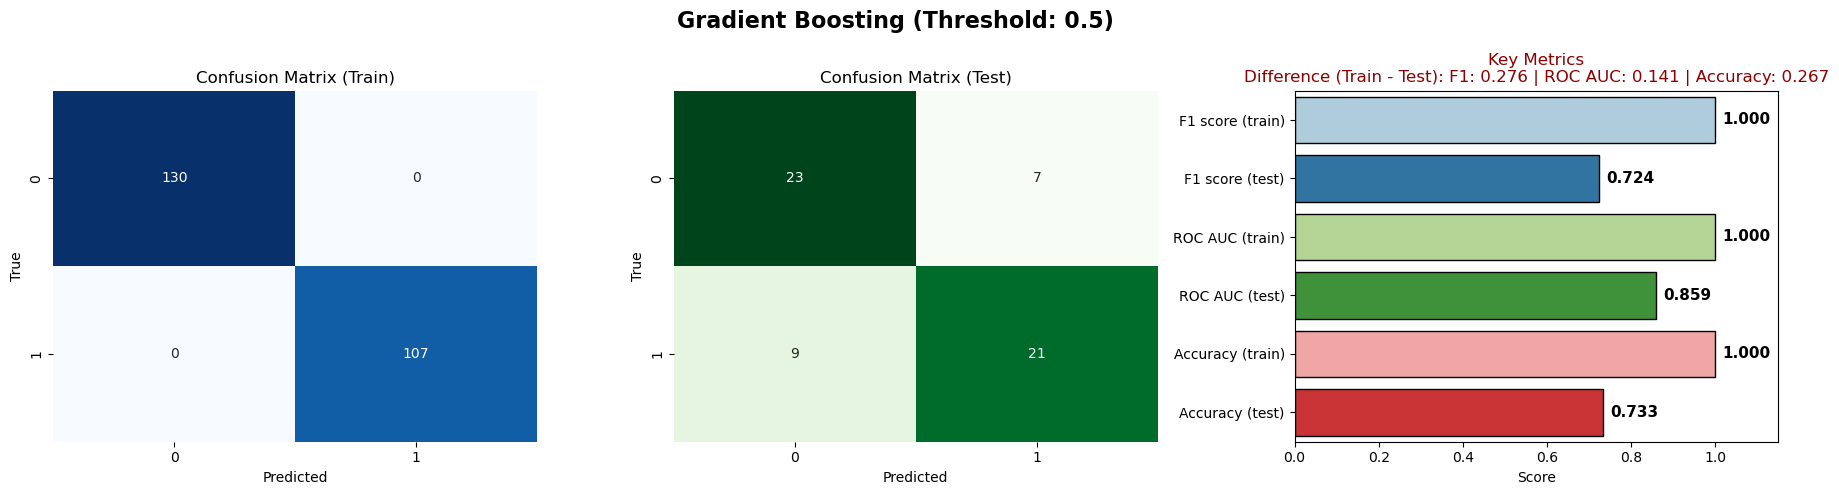

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.719,0.767,0.742,30.000
1,0.750,0.700,0.724,30.000
accuracy,0.733,0.733,0.733,0.733
macro avg,0.734,0.733,0.733,60.000
weighted avg,0.734,0.733,0.733,60.000


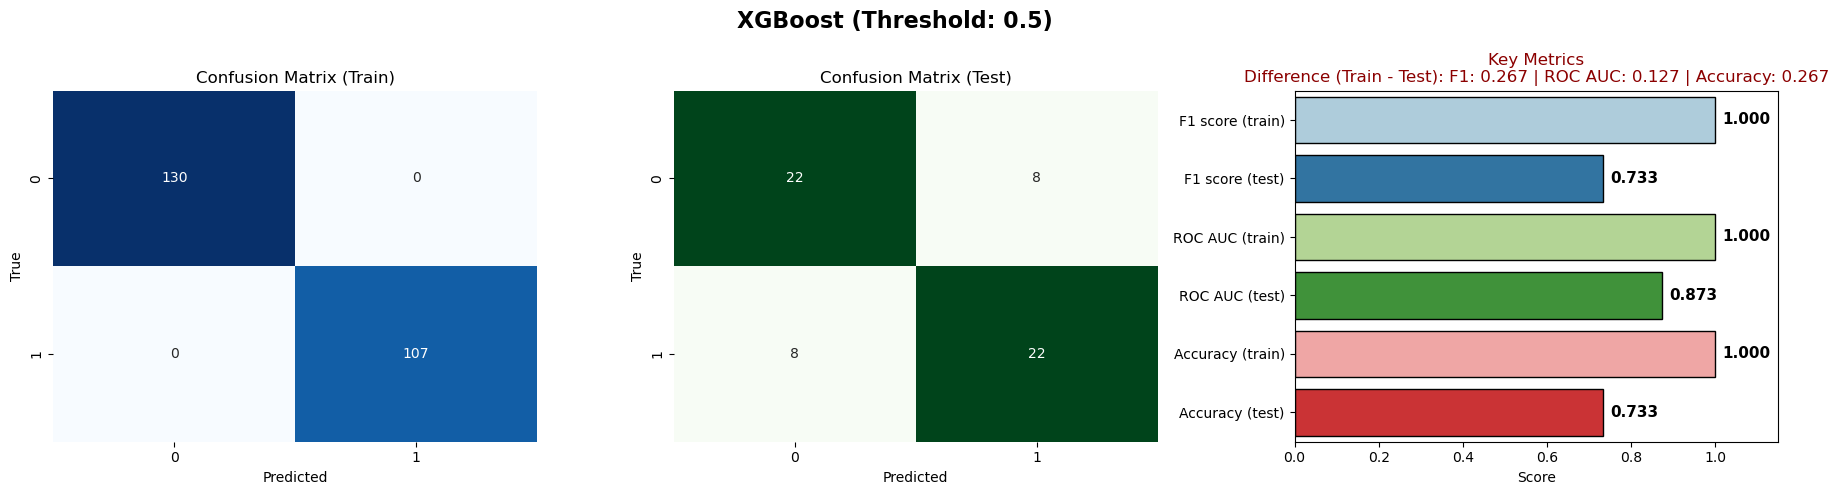

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.733,0.733,0.733,30.000
1,0.733,0.733,0.733,30.000
accuracy,0.733,0.733,0.733,0.733
macro avg,0.733,0.733,0.733,60.000
weighted avg,0.733,0.733,0.733,60.000


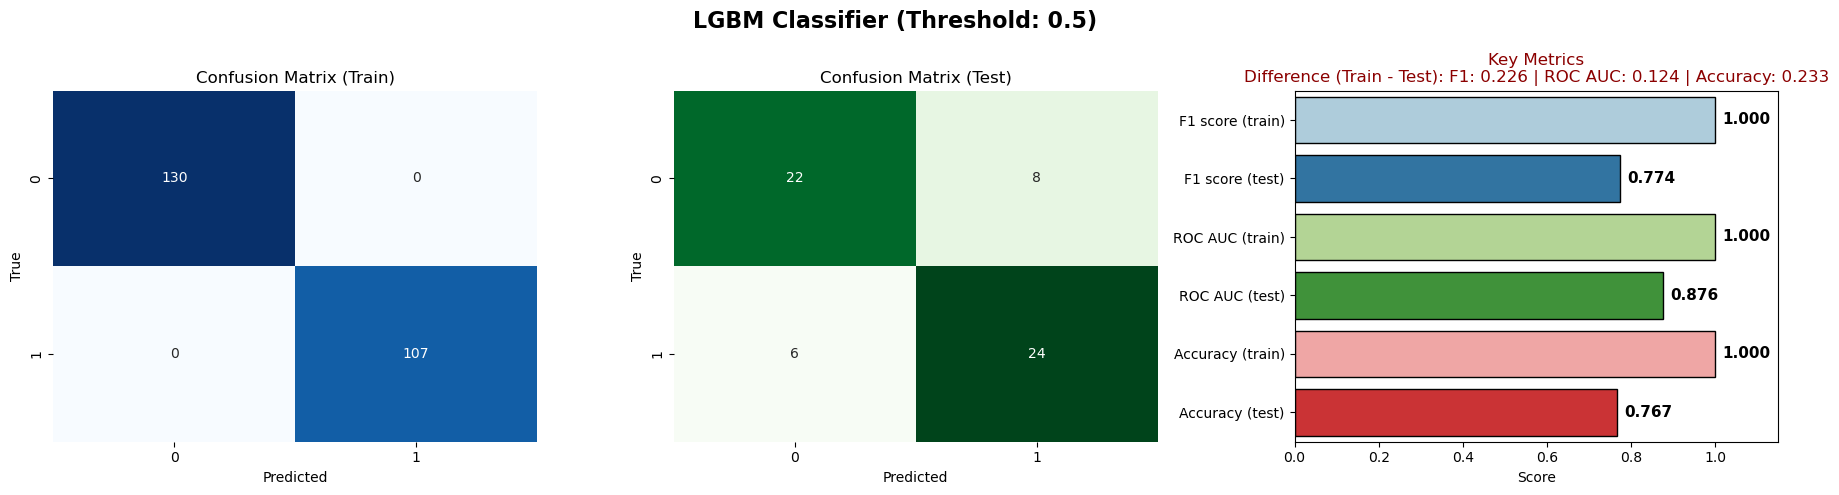

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.786,0.733,0.759,30.000
1,0.750,0.800,0.774,30.000
accuracy,0.767,0.767,0.767,0.767
macro avg,0.768,0.767,0.766,60.000
weighted avg,0.768,0.767,0.766,60.000


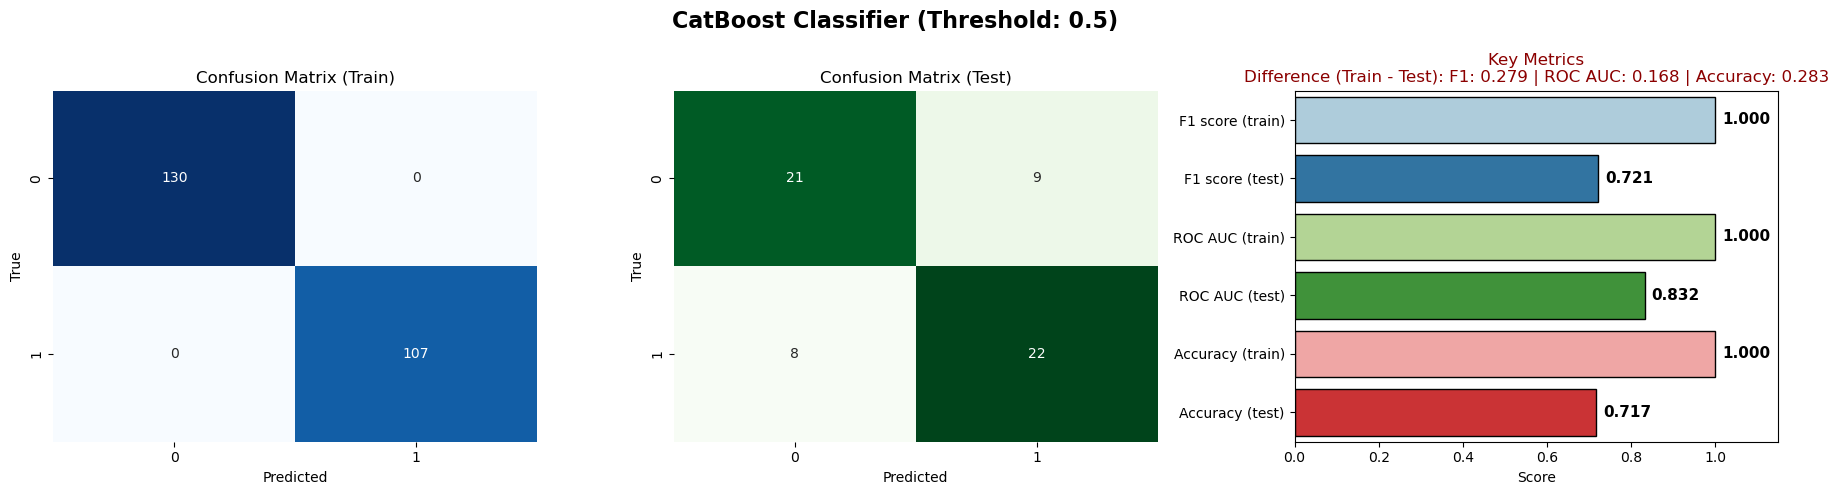

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.724,0.700,0.712,30.000
1,0.710,0.733,0.721,30.000
accuracy,0.717,0.717,0.717,0.717
macro avg,0.717,0.717,0.717,60.000
weighted avg,0.717,0.717,0.717,60.000


In [13]:
X_train_tr = preprocessor.fit_transform(X_train, y_train)
X_test_tr = preprocessor.transform(X_test)

# Dictionary to store trained models
trained_models = {}

for config in models_config:
    model_name = config['name']
    
    grid_search = GridSearchCV(
        estimator=config['estimator'], 
        param_grid=config['param_grid'], 
        scoring='recall', 
        cv=5, 
        n_jobs=-1
    )
    
    # Train the model 
    grid_search.fit(X_train_tr, y_train.values.ravel())
    
    # Save the best model to the dictionary 
    trained_models[model_name] = grid_search.best_estimator_
    
    # Dashboard
    display_model_dashboard(
        model_name, 
        grid_search.best_estimator_, 
        X_train_tr, y_train, 
        X_test_tr, y_test
    )

- During the experiments, the preprocessing pipeline was revised.
    - Replacing the standard scaler with the **Yeo-Johnson + MinMaxScaler** combination yielded the best results.

**Impact of Tuning on Overfitting (Comparison with Baseline):**

- Restricting tree depth (e.g., `max_depth=1` for `Random Forest`) proved effective:
    - the model stopped memorizing the training set (`Accuracy` on the train set dropped from an unrealistic $1.0$ to a realistic $0.852$), making it more robust on unseen data.
- Nevertheless, boosting models (`XGBoost`, `CatBoost`) still show a noticeable gap between Train and Test scores. On small medical datasets, such complex algorithms are often overkill.

**Medical Context (Focus on Recall):**
In the task of diagnosing cardiovascular diseases, the cost of an error is asymmetric. Missing a sick patient (**False Negative**) is far more dangerous than sending a healthy one for further testing (False Positive). Therefore, our key metric is **Recall for class 1**.

- Most "heavy" models (Gradient Boosting, CatBoost) showed a Recall of around $0.70–0.73$ (missing almost a third of the sick patients).
- The leaders in identifying sick patients were **LightGBM** and **Logistic Regression**, achieving a `Recall = 0.80` (finding $24$ out of $30$ sick patients).

**Final Model: Logistic Regression**

- GridSearch selected strong regularization for it (`C=0.1`, `solver='liblinear'`), which resulted in:
    - **No overfitting:** The difference between the training and test sets is less than $3\%$.
    - **Best balance:** The highest **F1-score** on the test set ($0.842$) and an excellent **Recall (0.800)**.
    - **Interpretability:** Unlike boosting algorithms, linear regression weights are easy to explain to medical professionals.

In [14]:
trained_models

{'Logistic Regression': LogisticRegression(C=0.1, random_state=0, solver='liblinear'),
 'SVC': LinearSVC(C=0.1, dual=False, random_state=0),
 'Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=1, n_estimators=200,
                        random_state=0),
 'Gradient Boosting': GradientBoostingClassifier(random_state=0, subsample=0.8),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=N

In [15]:
X_train, X_test, y_train, y_test = train_test_split(df_clean.drop(['target', ], axis=1), df_clean['target'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((237, 13), (60, 13))

## Final Model: Logistic Regression

In [16]:
#yeojohnson = ['Resting BP', 'ST Depression']#, 'Cholesterol', ]
#cont = ['Age', 'Resting BP', 'ST Depression']#, 'Cholesterol']

preprocessor = Pipeline(steps=[

    ('yeo_johnson', YeoJohnsonTransformer(variables=yeojohnson_col)),
    ('num_scaler', SklearnTransformerWrapper(transformer=MinMaxScaler(), variables=continuous))
])

In [17]:
X_train_tr = preprocessor.fit_transform(X_train)
X_test_tr = preprocessor.transform(X_test)
logreg = LogisticRegression(max_iter=1000, C=0.1, random_state=0, solver='liblinear')
logreg.fit(X_train_tr, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=0, solver='liblinear')

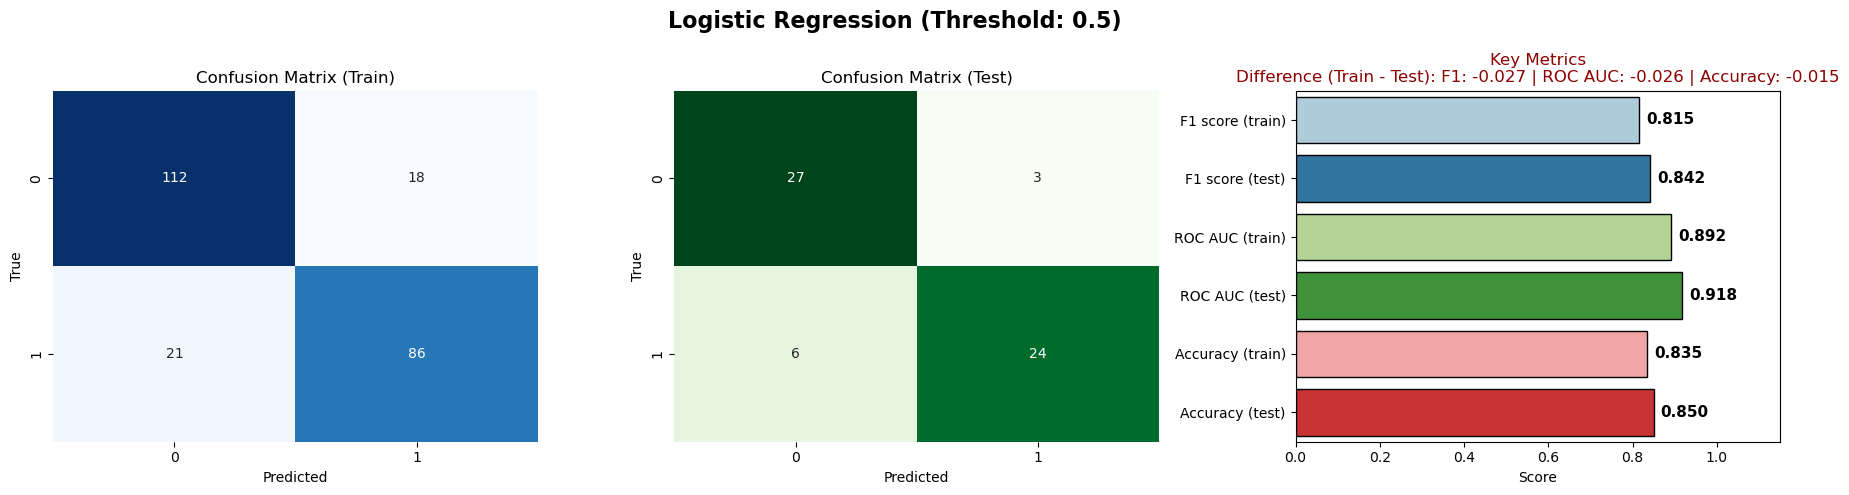

Classification Report (TEST data, Threshold = 0.5):


,precision,recall,f1-score,support
0,0.818,0.90,0.857,30.00
1,0.889,0.80,0.842,30.00
accuracy,0.850,0.85,0.850,0.85
macro avg,0.854,0.85,0.850,60.00
weighted avg,0.854,0.85,0.850,60.00


In [18]:
display_model_dashboard("Logistic Regression", logreg, X_train_tr, y_train, X_test_tr, y_test)

## Model Interpretability: SHAP Values and Regression Coefficients

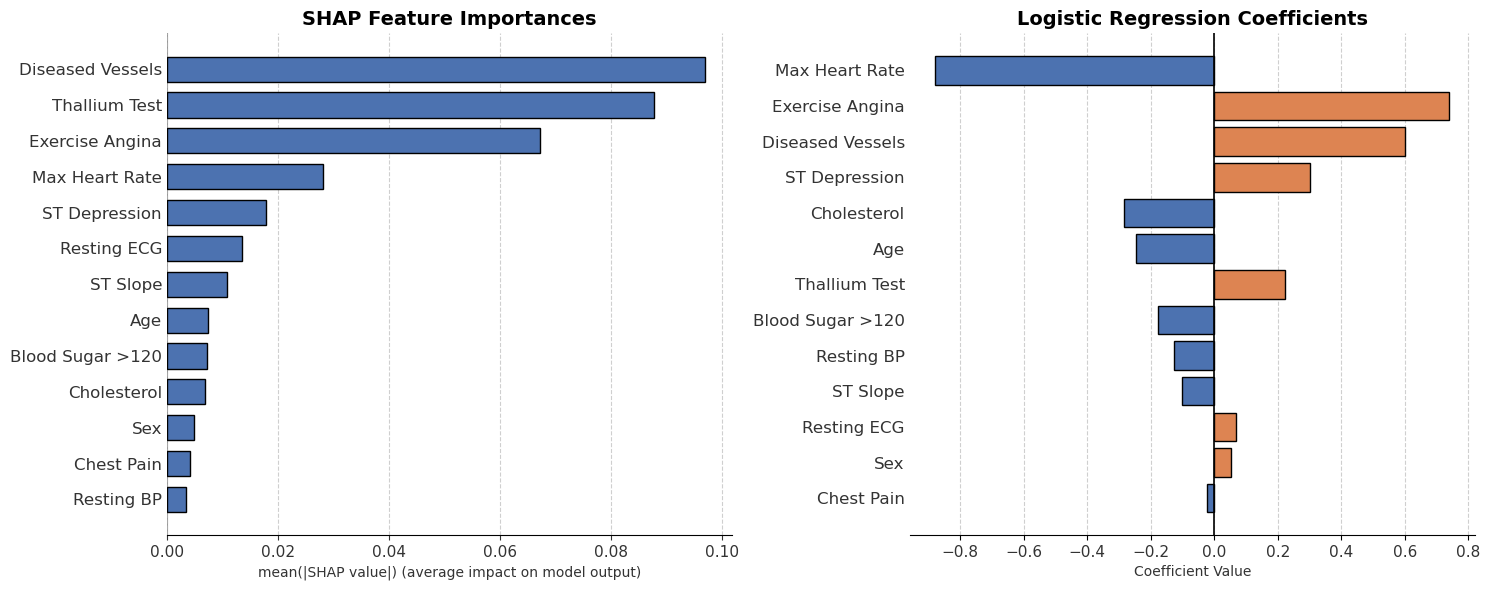

In [19]:
explainer_prob = shap.Explainer(lambda x: logreg.predict_proba(x)[:, 1], X_train_tr)

# Calculate SHAP values
shap_values = explainer_prob(X_test_tr)

feature_importance_logit(X_test_tr, shap_values, logreg)

**Consistency of Approaches (Top Predictors):**    
Both methods are unanimous in identifying the most important factors for diagnosis:

* `Diseased Vessels` (Number of diseased vessels)
* `Thallium Test` (Thallium stress test results)
* `Exercise Angina` (Exercise-induced angina)
* `Max Heart Rate` (Maximum heart rate achieved)

**Direction of Impact (Medical Logic):**    
The regression coefficients plot (on the right) perfectly reveals the physical meaning of the predictors:

* **Risk Factors (Blue bars, >0):** The presence of exercise-induced angina, an increase in the number of diseased vessels, and ST-segment depression on the ECG have strong positive weights. This makes sense: the worse these indicators are, the higher the probability of having cardiovascular disease.
* **Health Factors (Orange bars, <0):** The strongest negative coefficient belongs to `Max Heart Rate`. From a medical point of view, this is completely justified: the heart's ability to reach a high heart rate during a stress test (without irregularities) is a sign of a healthy cardiovascular system.

On the coefficients plot, a counterintuitive detail can be noticed: `Age` and `Cholesterol` have negative weights.

**Summary:** Although the model successfully identified key disease markers (ECG, heart rate, vessel condition), its global logic has a flaw in the form of negative weights for age and cholesterol. This artifact is a consequence of the small dataset size. With a small volume of data, regression coefficients become unstable and can exhibit such distortions. This is precisely why interpreting such a model requires individual SHAP analysis.

## Error Analysis

In [20]:
y_prob = logreg.predict_proba(X_test_tr)[:, 1]
y_pred = (y_prob >= 0.5).astype(int) 

errors = (pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "proba_1": y_prob
}, index=X_test.index)
.assign(correct=lambda d: d.y_true == d.y_pred))

errors = errors.loc[~errors["correct"]].join(X_test)  
errors.sort_values("proba_1", ascending=False)

,y_true,y_pred,proba_1,correct,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test
59,0,1,0.689997,False,51.0,1.0,1.0,125.0,213.0,0.0,2.0,125.0,1.0,1.4,1.0,1.0,3.0
250,0,1,0.636942,False,57.0,1.0,4.0,110.0,201.0,0.0,0.0,126.0,1.0,1.5,2.0,0.0,6.0
202,0,1,0.538678,False,57.0,1.0,3.0,150.0,126.0,1.0,0.0,173.0,0.0,0.2,1.0,1.0,7.0
52,1,0,0.407159,False,44.0,1.0,4.0,112.0,290.0,0.0,2.0,153.0,0.0,0.0,1.0,1.0,3.0
74,1,0,0.378535,False,44.0,1.0,4.0,110.0,197.0,0.0,2.0,177.0,0.0,0.0,1.0,1.0,3.0
301,1,0,0.329851,False,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0
66,1,0,0.296479,False,60.0,1.0,3.0,140.0,185.0,0.0,2.0,155.0,0.0,3.0,2.0,0.0,3.0
22,1,0,0.274204,False,58.0,1.0,2.0,120.0,284.0,0.0,2.0,160.0,0.0,1.8,2.0,0.0,3.0
145,1,0,0.258123,False,47.0,1.0,3.0,108.0,243.0,0.0,0.0,152.0,0.0,0.0,1.0,0.0,3.0


This table compiles all 9 cases from the test set where the model made an error.

**False Positive Errors (Top 3 rows):**
In these cases, the patients are actually healthy (`y_true = 0`), but the model predicted a disease.

* The patient with index **59** has exercise-induced angina (`Exercise Angina = 1.0`), one diseased vessel (`Diseased Vessels = 1.0`), and ST-segment depression. The model took these important predictors into account and yielded a high probability of risk. In medicine, such false alarms occur.

**False Negative Errors (Bottom 6 rows):**
In these cases, the patients are sick (`y_true = 1`), but the model classified them as healthy (probability below 0.5).

* Pay attention to patients **145** or **22**: they have no diseased vessels (`Diseased Vessels = 0.0`), no exercise-induced angina (`Exercise Angina = 0.0`), and their heart rate is sufficiently high. From the perspective of basic medical markers, they look normal. The model failed to recognize the disease.

**Error Confidence Analysis:**
The values of the erroneous probabilities (`proba_1`) lie in the range from $0.25$ to $0.69$. While in False Positive cases the model was indeed uncertain, yielding probabilities just above the $0.5$ threshold, the situation is different when missing sick patients. The minimum value of $0.25$ means that the algorithm was $75\%$ confident that the patient is absolutely healthy. Although the model does not make extreme errors (with $99\%$ confidence), its false overconfidence at the $70-75\%$ level during a False Negative diagnosis is a point requiring detailed investigation.

## Detailed Analysis of False Negatives

Number of False Negative errors: 6


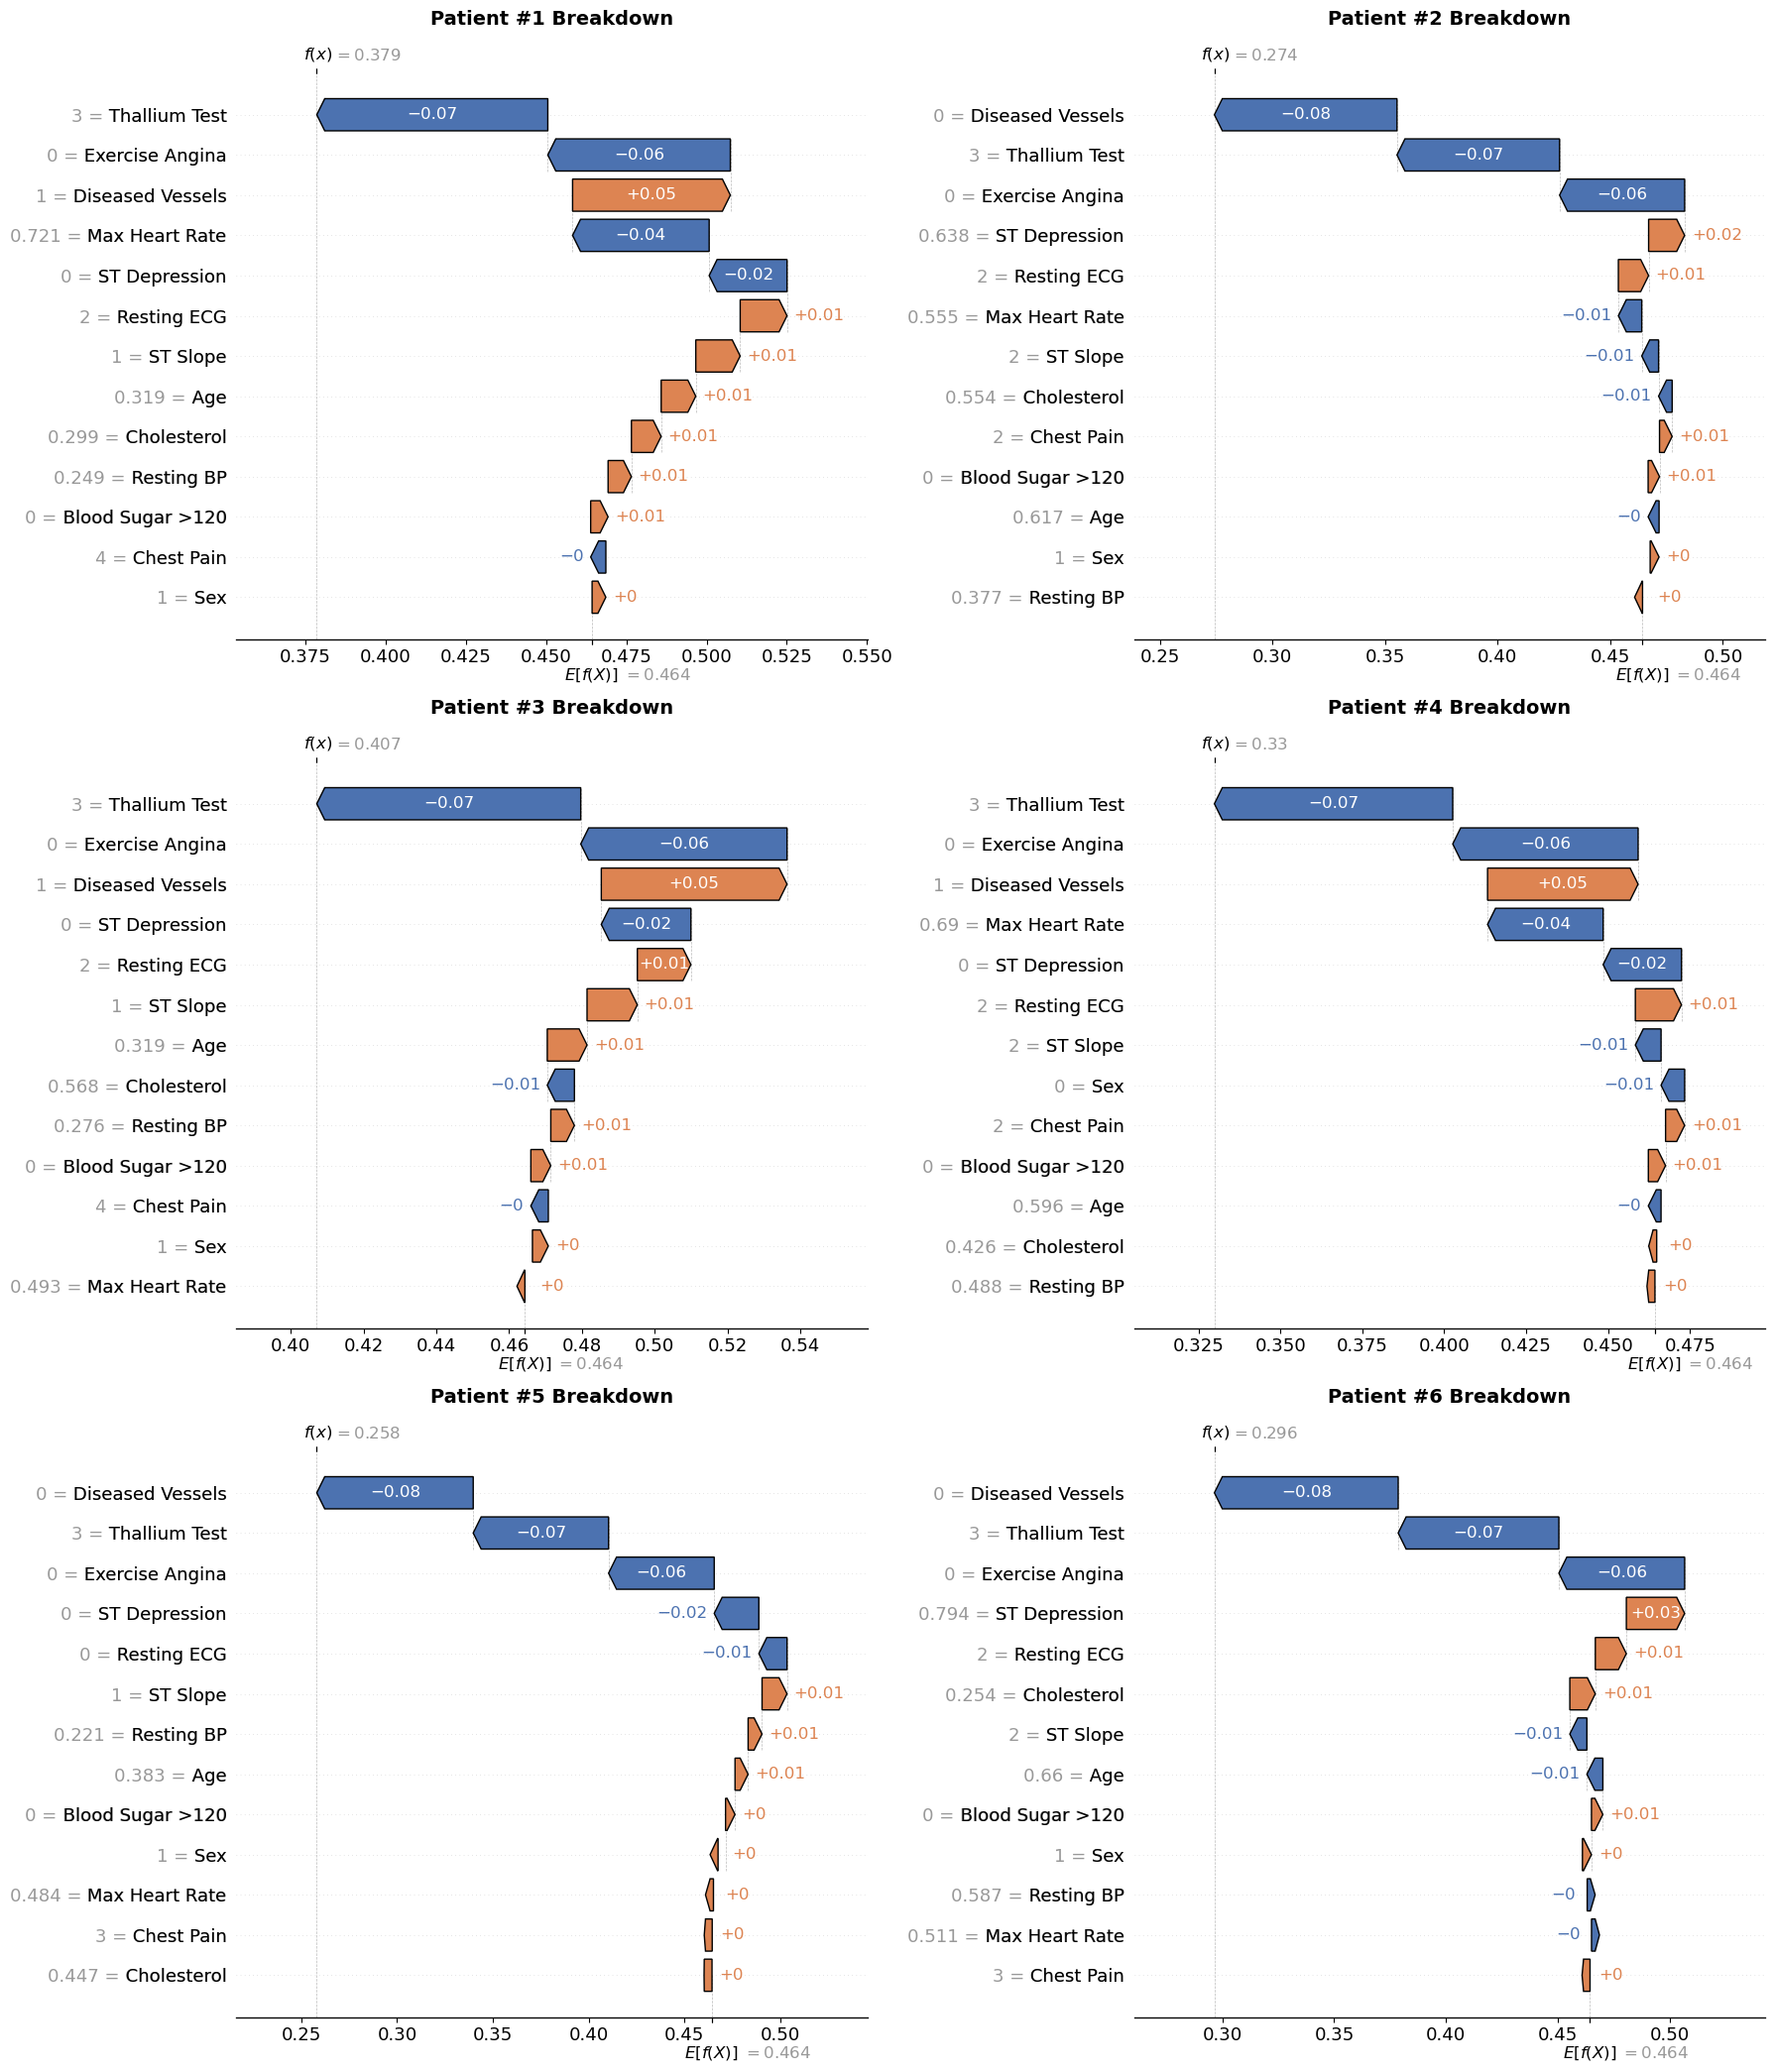

In [21]:
# Select only False Negative errors
errors_fn = X_test_tr[(y_test == 1) & (y_pred == 0)]

print(f"Number of False Negative errors: {len(errors_fn)}")

# Calculate SHAP values for incorrect diagnoses
shap_values_fn = explainer_prob(errors_fn)
shap_waterfalls_dashboard(shap_values_fn)

Starting from the average baseline risk in the sample of $46.4\%$ ($E[f(X)] = 0.464$), the algorithm encounters an atypical clinical picture in these six sick patients.

* **Ideal baseline tests:** In *each* of the $6$ patients, we see two massive blue arrows pushing the prediction towards zero (`target=0`, healthy). These are the results of `Thallium Test = 3` (normal) and `Exercise Angina = 0` (absence of exercise-induced angina).
* **Clear vessels:** For patients $\#2$, $\#5$, and $\#6$, the feature `Diseased Vessels = 0` (no diseased vessels) acts as the strongest blue arrow on the plot, driving the risk deep into the negative. Even for patients $\#1$, $\#3$, and $\#4$, who have one diseased vessel (an orange arrow to the right), this weight is not enough to outweigh the ideal results of the thallium test and the absence of angina.
* **Good ECG and heart rate indicators:** Most of them lack ST-segment depression (`ST Depression = 0`), and their maximum heart rate (`Max Heart Rate`) is at a sufficiently high level, which further convinces the model of their cardiovascular system's endurance.

**Overall Summary:**
Looking at these SHAP plots, it becomes clear that from a mathematical point of view, **the model worked logically**. Across all key metrics, these six individuals look like healthy people.

For the algorithm to learn to recognize such "invisible" cases, hyperparameter tuning alone is not enough—it will require additional, more sensitive medical features, as well as an increase in the sample size itself. A larger volume of data will give the algorithm the necessary statistical power to stop relying on single strong markers and learn to identify complex, hidden patterns of atypical disease progression.